In [1]:
from compest import *
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
offer_groups: Dict[str, List[Job]] = {}

## Modelling Variants of an Offer
If you have multiple offer ranges and you'd like to model the distribution, you can do that by providing multiple offers within a single offer group.

In [3]:
company = Company(f"Example", valuation=usd(50_000_000), share_price=usd(5.0), growth_percent=0, vesting_period=4)

offer_groups["Employee Performance"] = [
    Job(f"Low Performance",
        company,
        Salary(usd(150_000), bonus_percent=0, annual_growth_percent=1),
        company.one_off_stock_grant(usd(10_000))
    ),

    Job(f"Medium Performance",
        company,
        Salary(usd(150_000), bonus_percent=5, annual_growth_percent=5),
        company.one_off_stock_grant(usd(10_000)),
        company.annual_stock_grant(usd(5_000), vesting_years=5)
    ),

    Job(f"High Performance",
        company,
        Salary(usd(150_000), bonus_percent=10, annual_growth_percent=10),
        company.one_off_stock_grant(usd(10_000)),
        company.annual_stock_grant(usd(10_000), vesting_years=5)
    )
]

## Modelling Different Company Performance
You can also model the performance of different companies, or the same company with different growth rates, by providing multiple companies within a single offer group.

In [4]:
company_10 = Company("Example", valuation=usd(50_000_000), share_price=usd(5), growth_percent=10, vesting_period=5)
company_50 = Company("Example", valuation=usd(50_000_000), share_price=usd(5), growth_percent=50, vesting_period=5)
offer_groups[f"Company Performance"] = [
    Job(f"10% p.a.",
        company_10,
        Salary(usd(100_000), bonus_percent=5),
        company_10.one_off_stock_grant(usd(10_000)),
        company_10.annual_stock_grant(usd(5_000), vesting_years=5),
    ),

    Job(f"50% p.a.",
        company_50,
        Salary(usd(100_000), bonus_percent=5),
        company_50.one_off_stock_grant(usd(10_000)),
        company_50.annual_stock_grant(usd(5_000), vesting_years=5),
    )
]


## Modelling Cumulative Compensation
This plots the total compensation you are projected to accrue over time (assuming that you continue to hold any equity you receive).

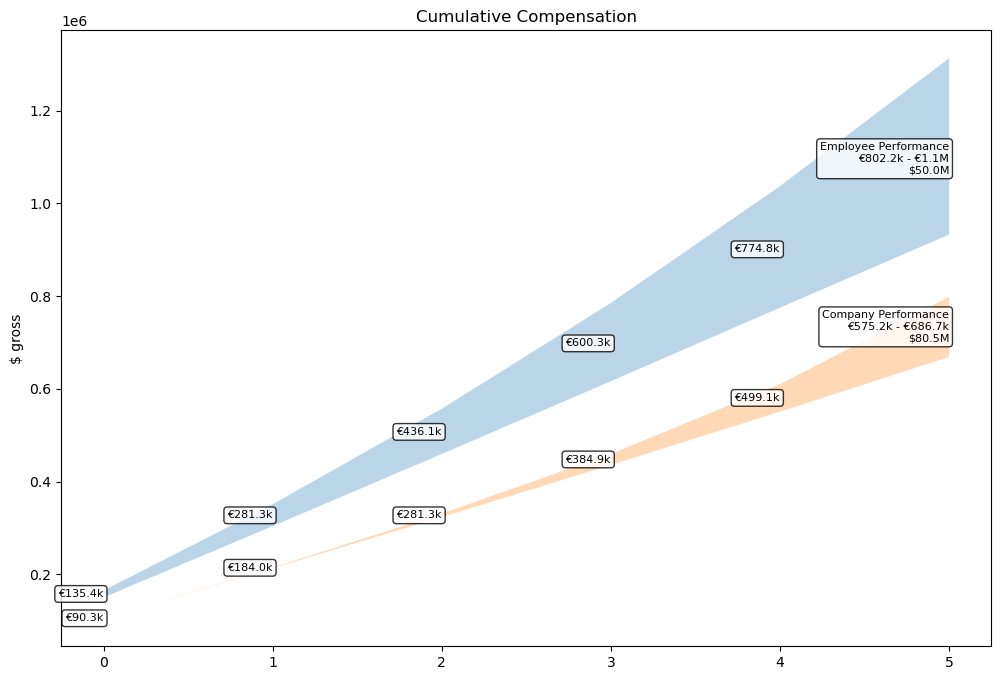

In [5]:

years = 5

render_cumulative_compensation(offer_groups, years)
plt.show()

## Modelling Annual Compensation
This model instead focuses on the annual compensation you are projected to receive, it may be better suited if you intend to sell your equity as soon as you receive it.

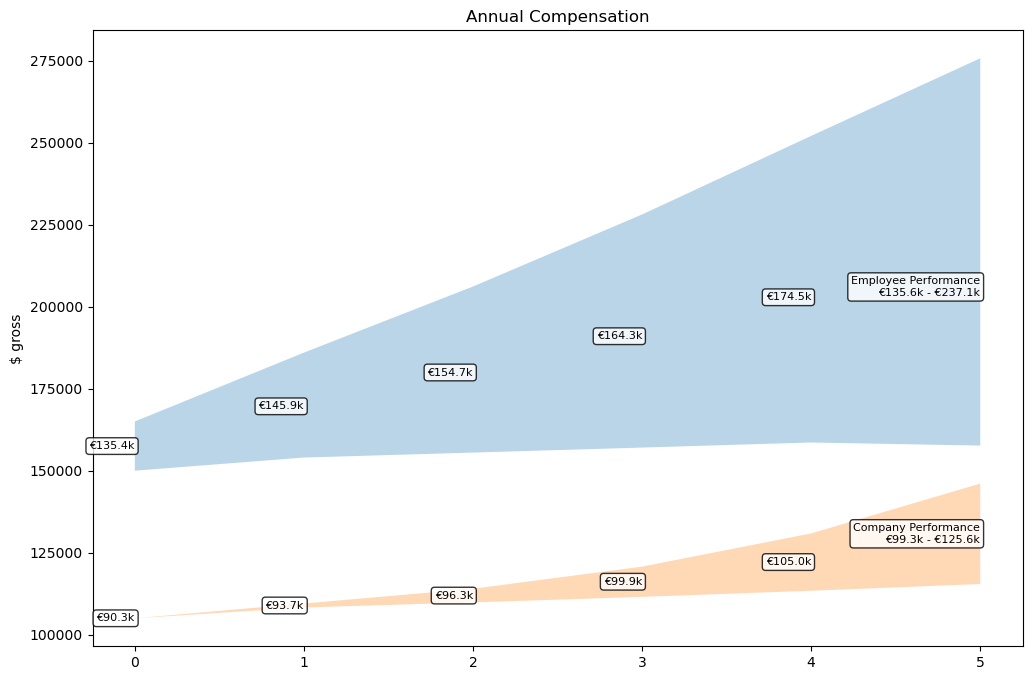

In [6]:
render_annual_compensation(offer_groups, years)
plt.show()

## Aggregate Breakdown
This shows the breakdown of your compensation opportunity for each offer group (including the lowest and highest offers).

In [7]:
summarize_offers(offer_groups, years)

,Company,Offer,Cumulative Compensation (Low),Cumulative Compensation (Mid),Cumulative Compensation (High),Share Price after 5 years,Valuation after 5 years
0,Example,Employee Performance,$932.8k,$1.1M,$1.3M,$5.0,$50.0M
1,Example,Company Performance,$668.9k,$733.7k,$798.5k,$8.1,$80.5M
